# Notebook B — Predicting Daily Price Changes (First Differences)
## 2024 US Presidential Election — Walk-Forward Machine Learning

**Target variable:** `price_change` = `polymarket_trump_prob(t) - polymarket_trump_prob(t-1)` — the one-day change in Trump's win probability.

**Why first differences instead of levels (Notebook A)?**
The price level is highly autocorrelated (AR(1) correlation ≈ 0.99). A model that simply predicts 'tomorrow ≈ today' achieves very low MAE without using any real information. By differencing, we remove that trivial signal and force every model to find *genuine* daily drivers of price movement. Predicting 0 (no change) is now the naive baseline.

**This notebook adds:**
- Relative sentiment features (Trump − Harris gap, sentiment surprise vs rolling mean)
- SBERT semantic embeddings on full daily text from all three sources
- FinBERT features from MediaCloud news headlines
- Candidate-specific text columns for TF-IDF
- Interaction term (sentiment gap × poll margin)

**Notebook A** (`models.ipynb`) targets the price *level* using the same pipeline.

## 1. Setup

Imports, style, and helper functions — identical to Notebook A. See that notebook for documentation on `get_cv_folds`, `score_fold`, etc.

In [1]:
import sys, os, warnings, itertools
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available")

from Functions.data_splits import get_cv_folds, get_test_split, validate_no_leakage, print_fold_summary
from Descriptive.house_style import (apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    REPUBLICAN, DEMOCRAT, NEUTRAL, PALETTE)
apply_style()
print("Setup OK")

Setup OK


## 2. Data Loading

We load the same `basetable.csv` as Notebook A. All 118+ features are available here and augmented further in the feature engineering step below.

**Date note:** The Polymarket scrape runs at ≈ 00:03 UTC each day. A row dated `2024-07-14` therefore captures the *end-of-day price for 2024-07-13*. This off-by-one was corrected in `basetable.ipynb` by subtracting 1 day from the raw Polymarket dates — ensuring social media and news features from day t correctly line up with the price movement during day t.

In [2]:
df = pd.read_csv('../Data/3_Gold/basetable.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

try:
    text_raw = pd.read_csv('../Data/3_Gold/text_raw_daily.csv', parse_dates=['date'])
    for col in ['bsky_text', 'reddit_text', 'news_text']:
        text_raw[col] = text_raw[col].fillna('')
    df = df.merge(text_raw[['date','bsky_text','reddit_text','news_text']],
                  on='date', how='left')
    for col in ['bsky_text','reddit_text','news_text']:
        df[col] = df[col].fillna('')
    HAS_TEXT = True
    print(f"Raw text merged: {text_raw.shape}")
except FileNotFoundError:
    print("text_raw_daily.csv not found -- run text_features.ipynb first")
    HAS_TEXT = False

print(f"Basetable shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

Raw text merged: (124, 4)
Basetable shape: (124, 132)
Date range: 2024-07-04 -> 2024-11-04


## 3. Feature Engineering

All new features are **strictly backward-looking**: they use data from day t−1 or earlier to predict the price change at the close of day t. The `shift(1)` calls below enforce this.

| Feature group | Rationale |
|---------------|-----------|
| `*_sentiment_gap` | Markets react to *relative* candidate sentiment, not absolute levels |
| `*_sent_surprise` | Deviation from a 7-day rolling mean captures unexpected shifts |
| `poll_margin_change` | Momentum in polling data may lead prediction markets |
| `interaction_sent_x_poll` | Non-linear combination: sentiment matters more when polls are close |
| Candidate text cols | Focused TF-IDF vocabulary (Trump/Harris sentences only) |

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# All new features are strictly backward-looking (no future leakage).
# shift(1) ensures feature at row t uses data from t-1 or earlier.
# ─────────────────────────────────────────────────────────────────────────────

# 1. RELATIVE SENTIMENT — Trump minus Harris
#    Rationale: markets respond to the *gap* between candidates.
df['bsky_sentiment_gap'] = df['bsky_trump_sentiment_avg'] - df['bsky_harris_sentiment_avg']
df['news_sentiment_gap'] = df['news_trump_sentiment_avg'] - df['news_harris_sentiment_avg']

# 2. SENTIMENT SURPRISE — deviation from 7-day rolling mean
#    Rationale: a surprise (large positive deviation from recent mean)
#    may move the market tomorrow. We shift(1) so the feature at row t
#    uses yesterday's surprise (fully known at prediction time).
for col, new in [('bsky_trump_sentiment_avg', 'bsky_sent_surprise'),
                 ('news_trump_sentiment_avg',  'news_sent_surprise'),
                 ('bsky_sentiment_gap',        'bsky_gap_surprise')]:
    rolling_mean = df[col].shift(1).rolling(7, min_periods=3).mean()
    df[new] = df[col].shift(1) - rolling_mean

# 3. POLL MOMENTUM — 1-day change in poll margin
df['poll_margin_change'] = df['poll_margin'].diff().shift(1)

# 4. ATTENTION ASYMMETRY — maps [0,1] share to [-1,+1]
df['bsky_attention_asymmetry'] = 2 * df['bsky_trump_post_share'] - 1

# 5. INTERACTION — sentiment gap x poll margin (confluence of signals)
df['interaction_sent_x_poll'] = df['bsky_sentiment_gap'].shift(1) * df['poll_margin']

# 6. CANDIDATE-SPECIFIC TEXT COLUMNS
#    Filter raw text to sentences mentioning each candidate.
#    Focused documents reduce TF-IDF noise for small corpora.
if HAS_TEXT:
    def filter_sentences(text, keywords):
        sentences = [s.strip() for s in text.replace('\n', '. ').split('.') if s.strip()]
        return ' '.join(s for s in sentences
                       if any(k in s.lower() for k in keywords))

    TRUMP_KW  = ['trump', 'donald', 'maga', 'republican']
    HARRIS_KW = ['harris', 'kamala', 'democrat', 'walz']

    for src in ['bsky', 'reddit', 'news']:
        raw_col = f'{src}_text'
        df[f'{src}_trump_text']  = df[raw_col].apply(
            lambda x: filter_sentences(x, TRUMP_KW))
        df[f'{src}_harris_text'] = df[raw_col].apply(
            lambda x: filter_sentences(x, HARRIS_KW))

    TEXT_COLS = [f'{src}_{cand}_text'
                 for src in ['bsky','reddit','news']
                 for cand in ['trump','harris']]
    print(f"Candidate-specific text columns ({len(TEXT_COLS)}):")
    for col in TEXT_COLS:
        empty = (df[col] == '').sum()
        avg_w = df[col].apply(lambda x: len(x.split())).mean()
        print(f"  {col:<30} avg {avg_w:5.0f} words/day  {empty} empty days")
else:
    TEXT_COLS = []

print("\nNew numeric features added:")
new_feats = ['bsky_sentiment_gap','news_sentiment_gap','bsky_sent_surprise',
             'news_sent_surprise','bsky_gap_surprise','poll_margin_change',
             'bsky_attention_asymmetry','interaction_sent_x_poll']
for f in new_feats:
    print(f"  {f}")

Candidate-specific text columns (6):
  bsky_trump_text                avg  2907 words/day  1 empty days
  bsky_harris_text               avg  1981 words/day  1 empty days


  reddit_trump_text              avg  9686 words/day  2 empty days
  reddit_harris_text             avg  8467 words/day  2 empty days


  news_trump_text                avg 12414 words/day  6 empty days
  news_harris_text               avg 12374 words/day  6 empty days

New numeric features added:
  bsky_sentiment_gap
  news_sentiment_gap
  bsky_sent_surprise
  news_sent_surprise
  bsky_gap_surprise
  poll_margin_change
  bsky_attention_asymmetry
  interaction_sent_x_poll


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SBERT — Semantic Embeddings on Full Daily Text
#
# Pre-computed features are loaded from sbert_features_cache.csv.
# The cache was built with all-MiniLM-L6-v2 (22M params, fixed pre-trained
# weights) on 50 sampled sentences per day per source, then PCA 384->5.
# No data leakage: SBERT weights are fixed (not trained on our data).
# To recompute: delete the cache file and re-run the pre-compute script.
# ─────────────────────────────────────────────────────────────────────────────
import os as _os, warnings as _w
_w.filterwarnings("ignore")

SBERT_CACHE = "../Data/3_Gold/sbert_features_cache.csv"

if not _os.path.exists(SBERT_CACHE):
    print(f"WARNING: {SBERT_CACHE} not found.")
    print("Run the pre-compute script to generate it: python _precompute_sbert.py")
    FULL_TEXT_SBERT_FEATS = []
else:
    sbert_cache = pd.read_csv(SBERT_CACHE, parse_dates=["date"])
    # Only merge columns not already in df
    _new_cols = [c for c in sbert_cache.columns if c != "date" and c not in df.columns]
    if _new_cols:
        df = df.merge(sbert_cache[["date"] + _new_cols], on="date", how="left")
    FULL_TEXT_SBERT_FEATS = [c for c in sbert_cache.columns if c != "date"]
    print(f"SBERT cache loaded: {len(FULL_TEXT_SBERT_FEATS)} features")
    print(FULL_TEXT_SBERT_FEATS)


SBERT cache loaded: 15 features
['sbert_bsky_pc1', 'sbert_bsky_pc2', 'sbert_bsky_pc3', 'sbert_bsky_pc4', 'sbert_bsky_pc5', 'sbert_reddit_pc1', 'sbert_reddit_pc2', 'sbert_reddit_pc3', 'sbert_reddit_pc4', 'sbert_reddit_pc5', 'sbert_news_pc1', 'sbert_news_pc2', 'sbert_news_pc3', 'sbert_news_pc4', 'sbert_news_pc5']


## 4. Target: Daily Price Change

`price_change = polymarket_trump_prob.diff()`

The standard deviation of `price_change` is ≈ 1.8 percentage points per day. A naive model that always predicts 0 achieves `MAE ≈ std × sqrt(π/2) ≈ 1.4 pp`. We report this as the baseline — any model with higher MAE is actively harmful.

Directional accuracy (DirAcc) is our main interpretability metric: 50 % = random coin flip, anything above is a positive signal, but only consistently above 55 % across multiple folds is practically meaningful.

Target  : price_change
Mean    : -0.00020
Std     : 0.01782
Max up  : 0.08000  |  Max down: -0.06000
Days up : 48.0%  |  Days down: 49.6%  |  Unchanged: 2.4%

Naive baseline MAE (predict 0): 0.01272
Every model must beat this to be useful.


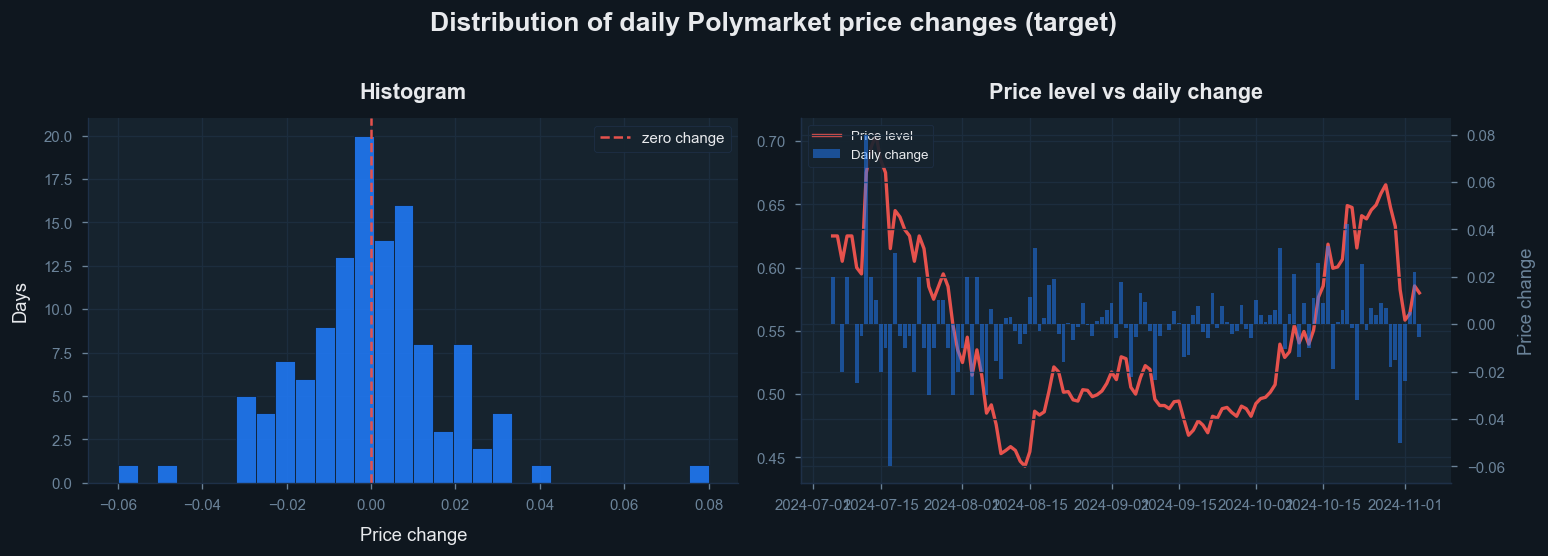

In [5]:
# ── Target variable: 1-day price change ──────────────────────────────────────
#
# We predict price_change[t] = price[t] - price[t-1]
#
# Why change instead of level?
#   In v1, predicting the price level let AR(1) (predict tomorrow = today)
#   dominate because Polymarket prices move slowly (~1-2 cents/day).
#   Predicting the CHANGE forces models to find genuine directional signal.
#   A naive baseline (predict 0) has MAE = mean(|actual change|).

df['price_change'] = df['polymarket_trump_prob'].diff()
TARGET = 'price_change'
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"Target  : {TARGET}")
print(f"Mean    : {df[TARGET].mean():.5f}")
print(f"Std     : {df[TARGET].std():.5f}")
print(f"Max up  : {df[TARGET].max():.5f}  |  Max down: {df[TARGET].min():.5f}")
print(f"Days up : {(df[TARGET] > 0).mean():.1%}  |  "
      f"Days down: {(df[TARGET] < 0).mean():.1%}  |  "
      f"Unchanged: {(df[TARGET] == 0).mean():.1%}")
naive_mae = df[TARGET].abs().mean()
print(f"\nNaive baseline MAE (predict 0): {naive_mae:.5f}")
print("Every model must beat this to be useful.")

# Plot
fig, axes = styled_fig(1, 2, figsize=(13, 4.5),
    title="Distribution of daily Polymarket price changes (target)")
ax1, ax2 = axes

ax1.hist(df[TARGET], bins=30, color=DEMOCRAT, alpha=0.85, edgecolor=BG_DARK)
ax1.axvline(0, color=REPUBLICAN, lw=1.5, ls='--', label='zero change')
style_ax(ax1, xlabel='Price change', ylabel='Days', title='Histogram', grid_axis='y')
ax1.legend()

ax2.plot(df['date'], df['polymarket_trump_prob'], color=REPUBLICAN, lw=2, label='Price level')
ax2_r = ax2.twinx()
ax2_r.bar(df['date'], df[TARGET], color=DEMOCRAT, alpha=0.5, width=0.8, label='Daily change')
ax2_r.set_ylabel('Price change', color=TEXT_MUTED)
ax2_r.tick_params(colors=TEXT_MUTED)
style_ax(ax2, title='Price level vs daily change')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Feature Groups

After filtering out columns with > 30 % missing values, features are grouped by data source for interpretability. The groups overlap — `FEAT_ALL` is their union.

**`FEAT_SENTIMENT`** — all sentiment-derived features: VADER mean/std/strong-ratios for Bluesky, Reddit (Trump & Harris), and news; FinBERT scores; sentiment gaps and surprises; interaction terms; SBERT principal components.

**Key feature by correlation with target:**  
`news_sentiment_gap` (Trump − Harris VADER news gap) achieves r = +0.31 — the strongest individual predictor in the dataset. Days when Trump receives more positive news coverage than Harris tend to see a higher prediction market price.

In [6]:
# Drop columns with >30% NaN
exclude_always = (['date', TARGET, 'polymarket_trump_prob'] +
                  (['bsky_text','reddit_text','news_text'] + TEXT_COLS if HAS_TEXT
                   else ['bsky_text','reddit_text','news_text'] if 'bsky_text' in df.columns else []))
numeric_candidates = [c for c in df.columns if c not in exclude_always
                      and df[c].dtype != object]
nan_frac = df[numeric_candidates].isnull().mean()
numeric_pool = nan_frac[nan_frac <= 0.30].index.tolist()

FEAT_AR = ['polymarket_trump_prob_lag1']

# Sentiment-derived features: means, gaps, std (controversy), strong-tone ratios,
# surprises (deviation from rolling mean), interaction terms, FinBERT scores,
# and SBERT principal components.
FEAT_SENTIMENT = [c for c in numeric_pool if any(x in c for x in [
    'sentiment', 'gap', 'surprise', 'attention_asym', 'interaction',
    'sent_std', 'strong_pos', 'strong_neg',
    'finbert', 'sbert_',
])]

FEAT_SOCIAL = [c for c in numeric_pool if any(x in c for x in
    ['bsky_', 'reddit_', 'net_', 'echo_'])]

FEAT_NEWS  = [c for c in numeric_pool if 'news_' in c or 'topic_' in c]

FEAT_POLLS = [c for c in numeric_pool if any(x in c for x in
    ['poll_', 'event_', 'debate_', 'days_to_'])]

FEAT_MACRO = [c for c in numeric_pool if any(x in c for x in
    ['sp500_','oil_','vix_','bond_','usd_','macro_'])]

FEAT_ALL = list(set(FEAT_AR + FEAT_SENTIMENT + FEAT_SOCIAL +
                    FEAT_NEWS + FEAT_POLLS + FEAT_MACRO))

print(f"Feature pool after 30% NaN filter: {len(numeric_pool)} columns")
print(f"  AR                 : {len(FEAT_AR)}")
print(f"  Sentiment / new    : {len(FEAT_SENTIMENT)}")
print(f"  Social media       : {len(FEAT_SOCIAL)}")
print(f"  News               : {len(FEAT_NEWS)}")
print(f"  Polls / Events     : {len(FEAT_POLLS)}")
print(f"  Macro / Finance    : {len(FEAT_MACRO)}")
print(f"  ALL combined       : {len(FEAT_ALL)}")
if HAS_TEXT:
    print(f"  Text cols          : {len(TEXT_COLS)}  (fitted per fold via ColumnTransformer)")

# Quick correlation check: which sentiment features correlate most with target?
sent_feats = [c for c in FEAT_SENTIMENT if c in df.columns]
corrs = df[sent_feats + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print()
print(f"Top sentiment features by |r| with {TARGET}:")
print(corrs.head(10).round(3).to_string())


Feature pool after 30% NaN filter: 142 columns
  AR                 : 1
  Sentiment / new    : 63
  Social media       : 55
  News               : 33
  Polls / Events     : 18
  Macro / Finance    : 32
  ALL combined       : 140
  Text cols          : 6  (fitted per fold via ColumnTransformer)

Top sentiment features by |r| with price_change:
news_sentiment_gap               0.313
sbert_news_pc4                   0.157
reddit_sentiment_gap             0.152
news_trump_finbert_avg           0.144
sbert_reddit_pc4                 0.142
news_trump_finbert_pos_ratio     0.141
news_finbert_gap                 0.137
sbert_news_pc1                   0.132
news_attention_asymmetry_lag1    0.114
sbert_news_pc3                   0.108


## 6. Walk-Forward CV Splits

Identical design to Notebook A — see Section 3 there for the full explanation of the time-respecting split strategy and the no-leakage guarantee.

```
Day:   1 ──────────────────────────────────────────────────────── 124
Fold 1: [====TRAIN====][ gap ][ VAL 14d ]                        TEST
Fold 2: [========TRAIN========][ gap ][ VAL 14d ]                TEST
Fold 3: [============TRAIN============][ gap ][ VAL 14d ]        TEST
                                                          [TEST 14d]
```

**Crucial difference vs Notebook A:** The target here is `price_change` (stationary), so the AR(1) baseline is simply predicting 0 every day.

In [7]:
folds = get_cv_folds(df, n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(df, test_days=14)

print("Walk-forward CV folds (expanding window, gap=1 day, 14-day held-out test):")
print_fold_summary(df, folds)
print(f"\nTest set: {df['date'].iloc[test_idx[0]].date()} -> "
      f"{df['date'].iloc[test_idx[-1]].date()}  ({len(test_idx)} rows)")

for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df, gap=1)
print("All folds pass leakage check.")

Walk-forward CV folds (expanding window, gap=1 day, 14-day held-out test):
Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-05    2024-07-31       27    2024-08-02    2024-08-28      27
   2    2024-07-05    2024-08-27       54    2024-08-29    2024-09-24      27
   3    2024-07-05    2024-09-23       81    2024-09-25    2024-10-21      27

Test set: 2024-10-22 -> 2024-11-04  (14 rows)
All folds pass leakage check.


## 7. Preprocessing Pipeline

Same `Pipeline(imputer → scaler → model)` structure as Notebook A. For text-augmented models a `ColumnTransformer` wraps both the numeric pipeline and a TF-IDF + SVD text pipeline, all fitted per fold on training data only.

In [8]:
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model),
    ])


def make_text_pipeline(model, numeric_cols, text_cols,
                        n_components=5, max_features=200):
    """
    Mixed pipeline: numeric + candidate-specific TF-IDF branches.

    Correct fit/transform schema per fold:
      fit   on X_train rows  -> learns vocabulary + IDF from training days only
      transform X_val        -> same frozen vectorizer, no refitting

    TF-IDF settings for small corpora (35-80 training days):
      min_df=1         : keep terms appearing even once in training
      max_features=200 : tight cap reduces overfitting risk
      ngram_range=(1,2): unigrams + bigrams
      sublinear_tf=True: log(1+tf) dampens high-frequency stop-like terms
      n_components=5   : compact LSA per source (6 sources = 30 text features)
    """
    numeric_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    text_transformers = []
    for col in text_cols:
        text_pipe = Pipeline([
            ('tfidf', TfidfVectorizer(
                max_features=max_features, min_df=1, max_df=0.98,
                ngram_range=(1, 2), sublinear_tf=True,
                stop_words='english',
            )),
            ('svd', TruncatedSVD(n_components=n_components, random_state=42)),
        ])
        text_transformers.append((f'text_{col}', text_pipe, col))

    ct = ColumnTransformer(
        transformers=[('numeric', numeric_transformer, numeric_cols)]
        + text_transformers,
        remainder='drop',
    )
    return Pipeline([('features', ct), ('model', model)])


def directional_accuracy(y_true, y_pred):
    """Fraction of non-zero-change days where the predicted direction is correct."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask]))


def score_fold(pipeline, feat_cols, train_idx, val_idx):
    X_tr = df.iloc[train_idx][feat_cols]
    y_tr = df.iloc[train_idx][TARGET].values
    X_va = df.iloc[val_idx][feat_cols]
    y_va = df.iloc[val_idx][TARGET].values
    p = clone(pipeline)
    p.fit(X_tr, y_tr)
    return mean_absolute_error(y_va, p.predict(X_va))


def eval_pipeline(pipeline, feat_cols, train_idx, val_idx):
    X_tr = df.iloc[train_idx][feat_cols]
    y_tr = df.iloc[train_idx][TARGET].values
    X_va = df.iloc[val_idx][feat_cols]
    y_va = df.iloc[val_idx][TARGET].values
    p = clone(pipeline)
    p.fit(X_tr, y_tr)
    y_pred = p.predict(X_va)
    return {
        'MAE':    mean_absolute_error(y_va, y_pred),
        'RMSE':   np.sqrt(mean_squared_error(y_va, y_pred)),
        'R2':     r2_score(y_va, y_pred),
        'DirAcc': directional_accuracy(y_va, y_pred),
        'y_val':  y_va,
        'y_pred': y_pred,
    }


print("Helpers defined.")

Helpers defined.


## 8. Hyperparameter Tuning

Manual walk-forward grid search. Grids are kept small to avoid timeouts; the goal is to find a reasonable regularisation strength, not to exhaustively search the space.

**Model zoo:**
- `AR(1)` — predict tomorrow = today's price change (always 0 after differencing)
- `Ridge` — L2 regularised regression, cannot zero out coefficients
- `Lasso` — L1, zeros out weak features (effective automatic feature selection)
- `ElasticNet` — mixture of L1 and L2
- `Lasso Sentiment` — Lasso using only sentiment + poll features
- `XGBoost` — gradient-boosted trees, captures non-linear interactions
- `Lasso + Text` / `XGBoost + Text` — above plus TF-IDF candidate text

In [9]:
# ── Parameter grids ──────────────────────────────────────────────────────────
# Walk-forward manual grid search: no sklearn GridSearchCV (it shuffles data).
# For text models, ColumnTransformer fits TF-IDF per fold automatically.
# Grids are kept small so tuning finishes within a reasonable time.

PARAM_GRIDS = {
    'AR(1)':          {'model__alpha': [1e-9], 'feats': [FEAT_AR]},
    'Ridge':          {'model__alpha': [0.1, 1, 10, 100, 500], 'feats': [FEAT_ALL]},
    'Lasso':          {'model__alpha': [1e-4, 0.001, 0.01, 0.05, 0.1], 'feats': [FEAT_ALL]},
    'ElasticNet':     {'model__alpha': [0.001, 0.01],
                       'model__l1_ratio': [0.3, 0.7], 'feats': [FEAT_ALL]},
    'Lasso Sentiment':{'model__alpha': [1e-4, 0.01, 0.1],
                       'feats': [FEAT_SENTIMENT + FEAT_POLLS + FEAT_AR]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost'] = {
        'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05], 'feats': [FEAT_ALL]}
if HAS_TEXT:
    PARAM_GRIDS['Lasso + Text'] = {
        'model__alpha': [0.01, 0.1],
        'feats': [FEAT_ALL], 'use_text': [True]}
    if HAS_XGB:
        # Single fixed combo for text+XGBoost (TF-IDF per fold is slow)
        PARAM_GRIDS['XGBoost + Text'] = {
            'model__n_estimators': [50], 'model__max_depth': [2],
            'model__learning_rate': [0.05],
            'feats': [FEAT_ALL], 'use_text': [True]}

BASE_ESTIMATORS = {
    'AR(1)':           Ridge(),
    'Ridge':           Ridge(),
    'Lasso':           Lasso(max_iter=10000),
    'ElasticNet':      ElasticNet(max_iter=10000),
    'Lasso Sentiment': Lasso(max_iter=10000),
    'Lasso + Text':    Lasso(max_iter=10000),
}
if HAS_XGB:
    BASE_ESTIMATORS['XGBoost']        = XGBRegressor(random_state=42, verbosity=0)
    BASE_ESTIMATORS['XGBoost + Text'] = XGBRegressor(random_state=42, verbosity=0)

naive_mae_cv = df.iloc[np.concatenate([va for _, va in folds])][TARGET].abs().mean()
print(f"Naive baseline (predict 0) CV MAE = {naive_mae_cv:.5f}")
print()

tuning_results = {}
TUNED_MODELS   = {}

for model_name, grid in PARAM_GRIDS.items():
    feat_cols = grid.get('feats', [FEAT_ALL])[0]
    use_text  = bool(grid.get('use_text', [False])[0] if isinstance(
                    grid.get('use_text', False), list) else grid.get('use_text', False))

    param_keys = [k for k in grid if k.startswith('model__')]
    param_vals = [grid[k] for k in param_keys]

    def _make(estimator, _fc=feat_cols, _ut=use_text):
        if _ut:
            nc = [c for c in _fc if c not in TEXT_COLS]
            return make_text_pipeline(estimator, nc, TEXT_COLS)
        return make_pipeline(estimator)

    if model_name == 'AR(1)':
        pipe = make_pipeline(Ridge(alpha=1e-9))
        fold_maes = [score_fold(pipe, feat_cols, tr, va) for tr, va in folds]
        tuning_results[model_name] = {'best_mae': np.mean(fold_maes), 'best_params': {}}
        TUNED_MODELS[model_name] = (pipe, feat_cols, False)
        print(f"AR(1)                  fixed  |  CV MAE = {np.mean(fold_maes):.5f}")
        continue

    best_mae, best_params, best_pipe = np.inf, None, None
    all_combos = []
    for combo in itertools.product(*param_vals):
        params = dict(zip(param_keys, combo))
        est = clone(BASE_ESTIMATORS[model_name])
        est.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
        pipe = _make(est)
        fc_eff = feat_cols + TEXT_COLS if use_text else feat_cols
        fold_maes = [score_fold(pipe, fc_eff, tr, va) for tr, va in folds]
        mean_mae = np.mean(fold_maes)
        all_combos.append({'params': params, 'mean_mae': mean_mae})
        if mean_mae < best_mae:
            best_mae, best_params, best_pipe = mean_mae, params, pipe

    eff_feats = feat_cols + TEXT_COLS if use_text else feat_cols
    tuning_results[model_name] = {'best_params': best_params, 'best_mae': best_mae,
                                   'all_results': all_combos}
    TUNED_MODELS[model_name] = (best_pipe, eff_feats, use_text)
    print(f"{model_name:<22} {len(all_combos):>3} combos  |  "
          f"best MAE={best_mae:.5f}  |  {best_params}")

print()
print("Tuning complete.")


Naive baseline (predict 0) CV MAE = 0.01009

AR(1)                  fixed  |  CV MAE = 0.01275


Ridge                    5 combos  |  best MAE=0.01041  |  {'model__alpha': 500}


Lasso                    5 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}
ElasticNet               4 combos  |  best MAE=0.01092  |  {'model__alpha': 0.01, 'model__l1_ratio': 0.7}


Lasso Sentiment          3 combos  |  best MAE=0.01027  |  {'model__alpha': 0.01}


XGBoost                  4 combos  |  best MAE=0.01102  |  {'model__n_estimators': 50, 'model__max_depth': 2, 'model__learning_rate': 0.05}


Lasso + Text             2 combos  |  best MAE=0.01030  |  {'model__alpha': 0.1}


XGBoost + Text           1 combos  |  best MAE=0.01112  |  {'model__n_estimators': 50, 'model__max_depth': 2, 'model__learning_rate': 0.05}

Tuning complete.


## 9. Cross-Validation Results

Same metrics as Notebook A. For the price-change target, MAE is measured in daily percentage-point changes (typical move ≈ 1.8 pp/day). A model with DirAcc > 55 % consistently across folds would be economically interesting — it implies the features contain information about *which direction* the market will move before it prices it in.

In [10]:
cv_results = []
for model_name, (pipeline, feat_cols, use_text) in TUNED_MODELS.items():
    for fold_i, (train_idx, val_idx) in enumerate(folds, 1):
        m = eval_pipeline(pipeline, feat_cols, train_idx, val_idx)
        cv_results.append({'Model': model_name, 'Fold': fold_i,
                           'MAE': m['MAE'], 'RMSE': m['RMSE'],
                           'R2': m['R2'], 'DirAcc': m['DirAcc']})

cv_df = pd.DataFrame(cv_results)
summary = (cv_df.groupby('Model')[['MAE','RMSE','R2','DirAcc']]
           .agg(['mean','std']).round(5))
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.sort_values('MAE_mean')

print("Walk-forward CV -- tuned models (mean +/- std across 3 folds):")
print(f"Naive baseline (predict 0) MAE = {naive_mae_cv:.5f}")
print()
print(f"{'Model':<24} {'MAE':>14} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 68)
for m in summary.index:
    print(f"{m:<24} "
          f"{summary.loc[m,'MAE_mean']:.4f}+/-{summary.loc[m,'MAE_std']:.4f}  "
          f"{summary.loc[m,'RMSE_mean']:.4f}  "
          f"{summary.loc[m,'R2_mean']:>8.3f}  "
          f"{summary.loc[m,'DirAcc_mean']:>8.1%}")

Walk-forward CV -- tuned models (mean +/- std across 3 folds):
Naive baseline (predict 0) MAE = 0.01009

Model                               MAE     RMSE       R2    DirAcc
--------------------------------------------------------------------
Lasso Sentiment          0.0103+/-0.0022  0.0137    -0.094     46.3%
Lasso + Text             0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso                    0.0103+/-0.0022  0.0137    -0.102     46.3%
Ridge                    0.0104+/-0.0027  0.0134    -0.041     53.8%
ElasticNet               0.0109+/-0.0030  0.0142    -0.163     43.8%
XGBoost                  0.0110+/-0.0029  0.0149    -0.284     49.0%
XGBoost + Text           0.0111+/-0.0032  0.0150    -0.322     48.9%
AR(1)                    0.0127+/-0.0058  0.0160    -0.461     47.7%


## 10. Results

The left panel shows fold-by-fold MAE relative to the naive 0-prediction baseline (red dashed line). The right panel shows mean ± std CV MAE. Note that Lasso often matches the naive baseline exactly, because its regularisation drives all coefficients to zero when the signal is weak — this is not a bug, it is Lasso correctly learning that predicting 0 is optimal.

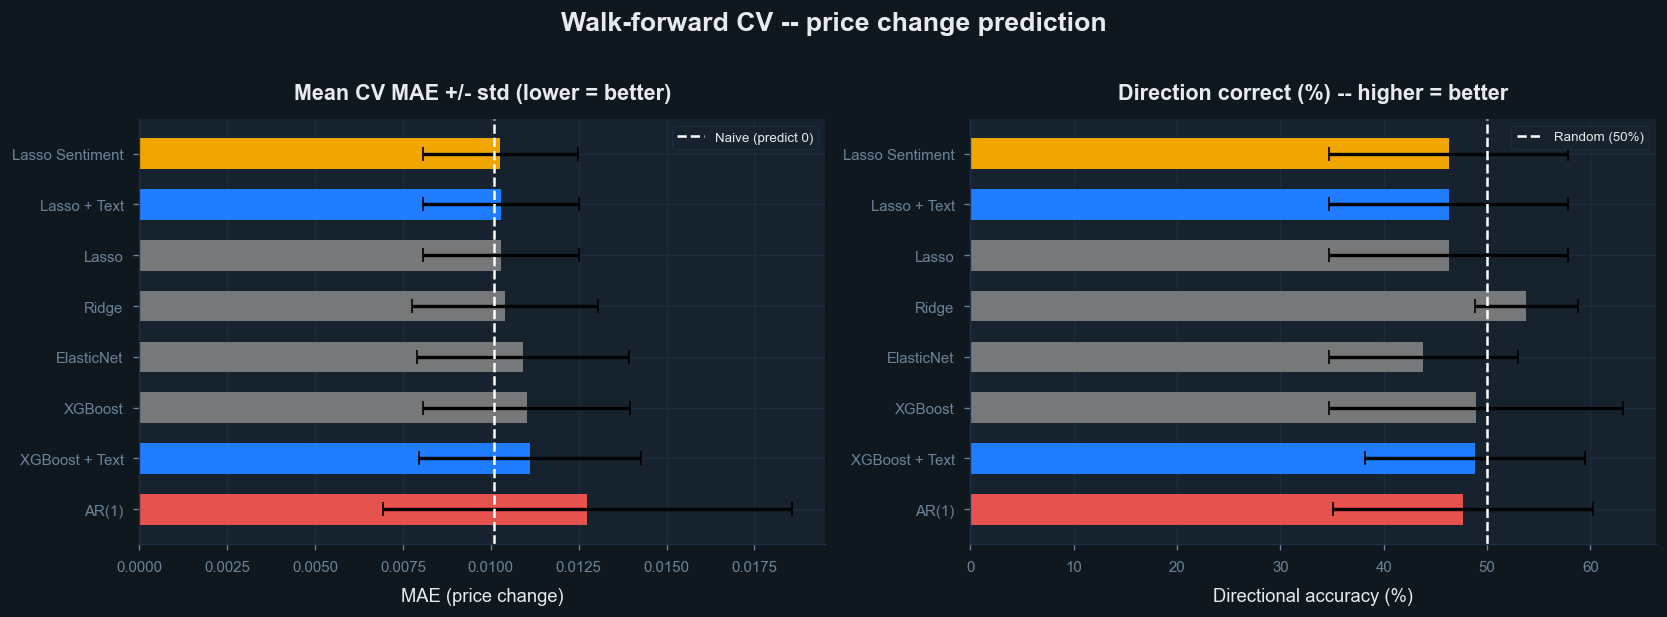

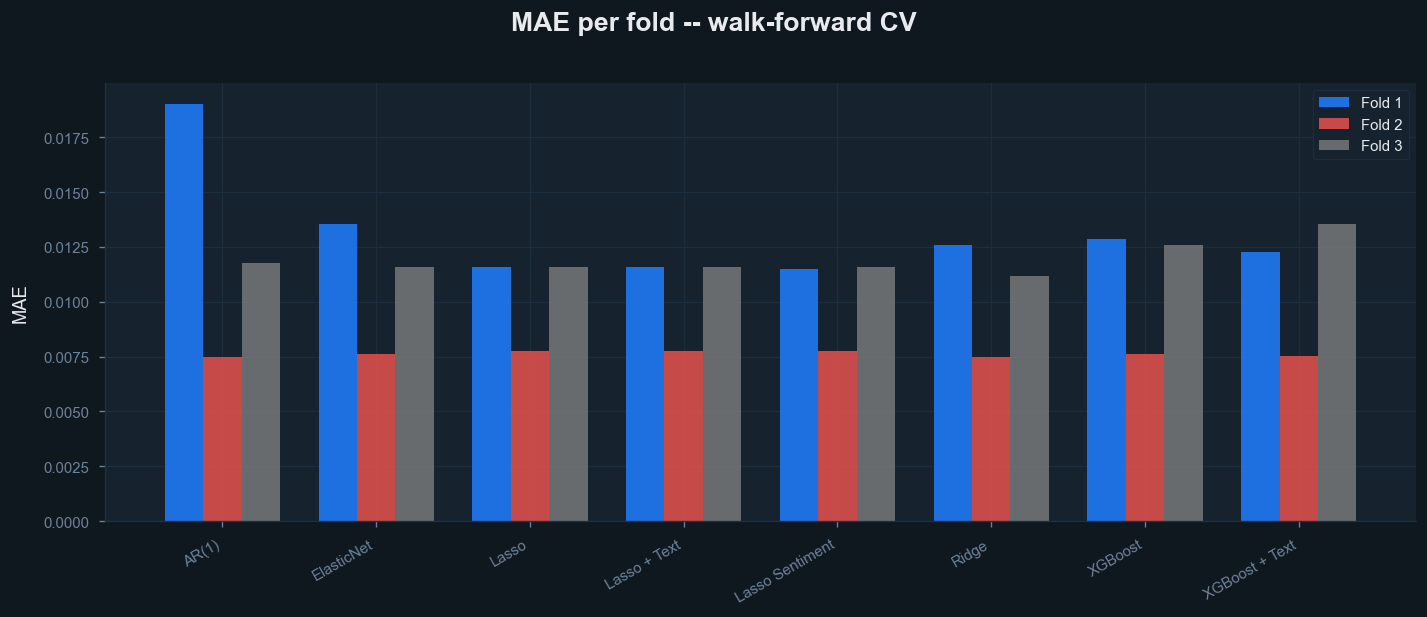

In [11]:
models_ord = summary.index.tolist()
means = summary['MAE_mean'].values
stds  = summary['MAE_std'].values

fig, axes = styled_fig(1, 2, figsize=(14, 5),
    title="Walk-forward CV -- price change prediction")
ax1, ax2 = axes

colors = [DEMOCRAT if 'Text' in m else REPUBLICAN if 'AR' in m
          else '#f0a500' if 'Sentiment' in m else NEUTRAL for m in models_ord]
ax1.barh(models_ord[::-1], means[::-1], xerr=stds[::-1],
         color=colors[::-1], capsize=4, height=0.6)
ax1.axvline(naive_mae_cv, color='white', ls='--', lw=1.5, label='Naive (predict 0)')
style_ax(ax1, xlabel='MAE (price change)', title='Mean CV MAE +/- std (lower = better)', grid_axis='x')
ax1.legend(fontsize=8)

dir_means = summary['DirAcc_mean'].values
dir_stds  = summary['DirAcc_std'].values
ax2.barh(models_ord[::-1], dir_means[::-1]*100, xerr=dir_stds[::-1]*100,
         color=colors[::-1], capsize=4, height=0.6)
ax2.axvline(50, color='white', ls='--', lw=1.5, label='Random (50%)')
style_ax(ax2, xlabel='Directional accuracy (%)',
         title='Direction correct (%) -- higher = better', grid_axis='x')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Per-fold breakdown
fig2, ax = styled_fig(1, 1, figsize=(12, 5),
    title="MAE per fold -- walk-forward CV")
fold_data = cv_df.pivot_table(index='Model', columns='Fold', values='MAE')
x = np.arange(len(fold_data))
w = 0.25
for fi, (fold, col) in enumerate(zip([1, 2, 3], [DEMOCRAT, REPUBLICAN, NEUTRAL])):
    if fold in fold_data.columns:
        ax.bar(x + fi*w, fold_data[fold], w, label=f'Fold {fold}', color=col, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(fold_data.index, rotation=30, ha='right', color=TEXT_PRIMARY)
style_ax(ax, ylabel='MAE', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Predictions vs Actual

The model with the highest CV directional accuracy is shown. Green dots = correct direction prediction; red dots = wrong direction. Correct direction should appear more often than 50 % for the model to be useful.

Best model by CV directional accuracy: Ridge
  CV MAE    : 0.0104 +/- 0.0027
  CV DirAcc : 53.8% +/- 5.0%

Note: Lasso/ElasticNet have lowest CV MAE but predict 0 for every day.
They are excluded from the prediction plot because a flat line
carries no information about which features drive price moves.


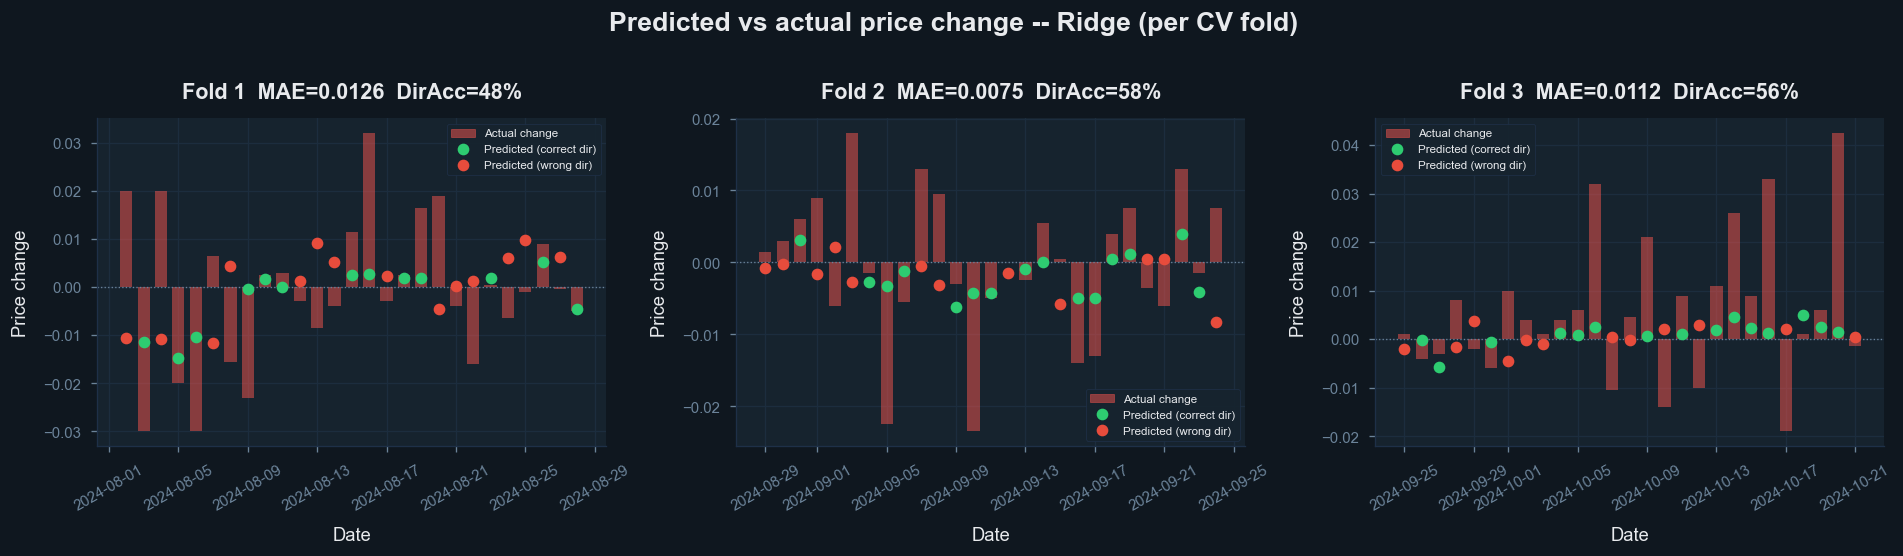

In [12]:
import matplotlib.lines as mlines

# Select model by directional accuracy for visualisation.
# Lasso/ElasticNet win on CV MAE because they predict ~0 every day
# (equivalent to the naive baseline). A flat prediction line gives no
# insight. XGBoost/Ridge actually produce non-trivial predictions.
best_name = summary['DirAcc_mean'].idxmax()
best_pipe, best_feats, _use_text = TUNED_MODELS[best_name]
print(f'Best model by CV directional accuracy: {best_name}')
print(f'  CV MAE    : {summary.loc[best_name,"MAE_mean"]:.4f} +/- {summary.loc[best_name,"MAE_std"]:.4f}')
print(f'  CV DirAcc : {summary.loc[best_name,"DirAcc_mean"]:.1%} +/- {summary.loc[best_name,"DirAcc_std"]:.1%}')
print()
print('Note: Lasso/ElasticNet have lowest CV MAE but predict 0 for every day.')
print('They are excluded from the prediction plot because a flat line')
print('carries no information about which features drive price moves.')

fig, axes = styled_fig(1, 3, figsize=(16, 4.5),
    title=f'Predicted vs actual price change -- {best_name} (per CV fold)')

for fi, (ax, (tr, va)) in enumerate(zip(axes, folds)):
    p = clone(best_pipe)
    p.fit(df.iloc[tr][best_feats], df.iloc[tr][TARGET])
    y_va = df.iloc[va][TARGET].values
    y_pr = p.predict(df.iloc[va][best_feats])
    dates = df.iloc[va]['date']

    # Colour each prediction dot: green = correct direction, red = wrong
    for d, yv, yp in zip(dates, y_va, y_pr):
        ax.bar(d, yv, color=REPUBLICAN, alpha=0.55, width=0.7)
        correct = (yv != 0) and (np.sign(yv) == np.sign(yp))
        ax.plot(d, yp, marker='o',
                color='#2ecc71' if correct else '#e74c3c',
                markersize=6, zorder=5)

    h1 = mpatches.Patch(color=REPUBLICAN, alpha=0.55, label='Actual change')
    h2 = mlines.Line2D([], [], color='#2ecc71', marker='o', ls='',
                       label='Predicted (correct dir)', markersize=6)
    h3 = mlines.Line2D([], [], color='#e74c3c', marker='o', ls='',
                       label='Predicted (wrong dir)', markersize=6)
    ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls=':')
    mae_f = mean_absolute_error(y_va, y_pr)
    da_f  = directional_accuracy(y_va, y_pr)
    style_ax(ax, xlabel='Date', ylabel='Price change',
             title=f'Fold {fi+1}  MAE={mae_f:.4f}  DirAcc={da_f:.0%}')
    ax.legend(handles=[h1, h2, h3], fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 12. Feature Importance

**Left (Ridge coefficients):** Ridge cannot zero out features, so all features receive a non-zero coefficient. Large absolute values indicate strong association with price changes.

**Right (XGBoost gain):** Average gain per feature across all trees.

Look for the `sbert_*`, `*_finbert_*`, and `*_sentiment_gap` features — these are the richer representations added in this notebook.

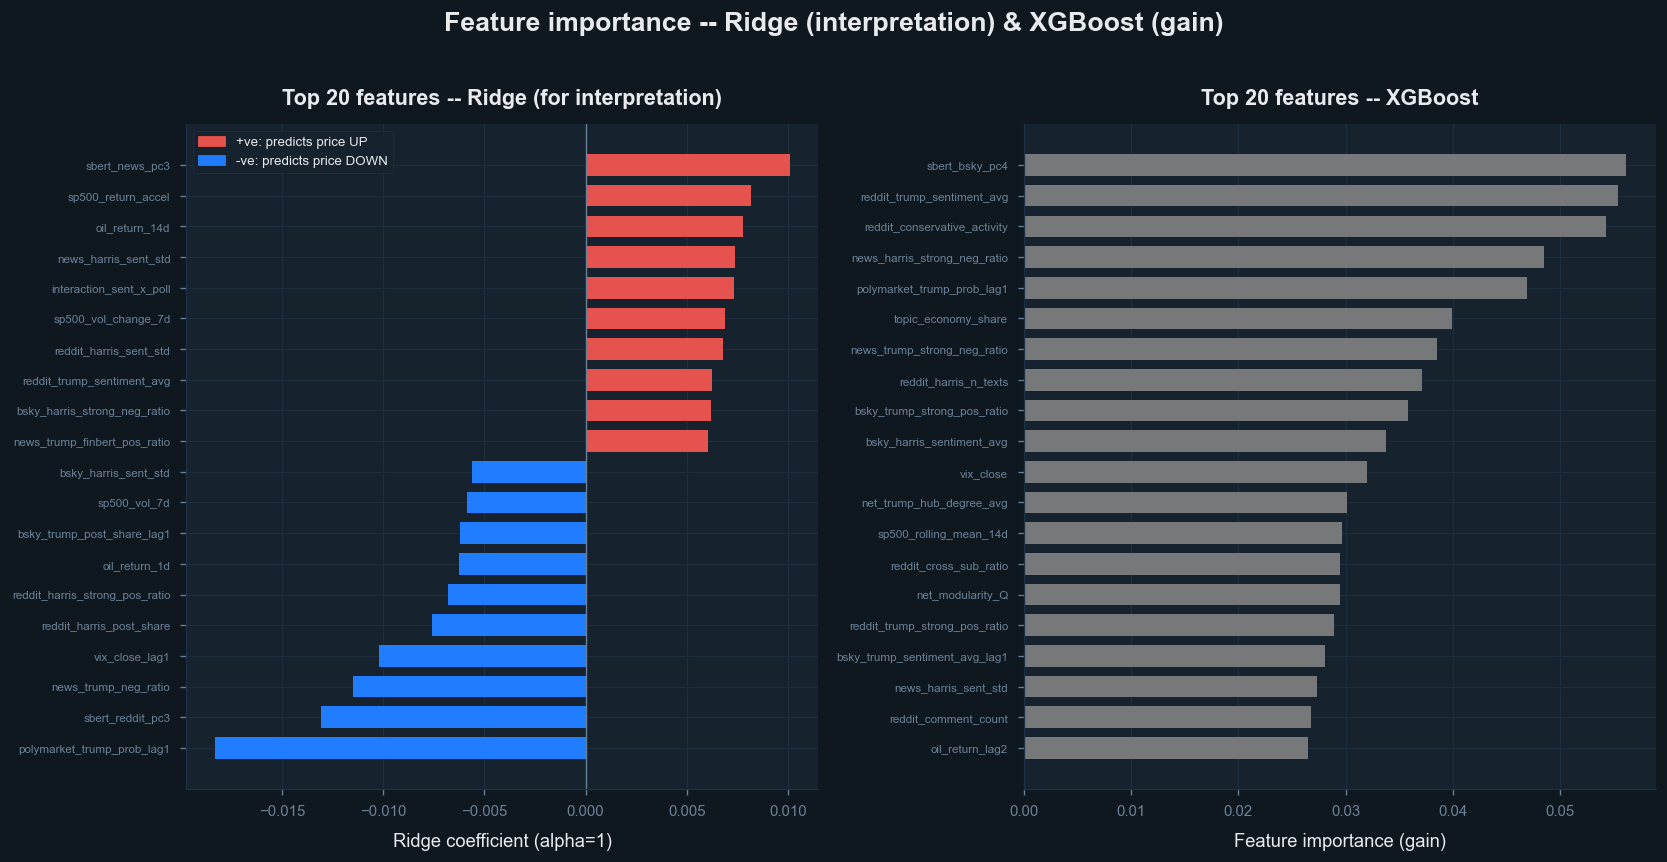

In [13]:
import matplotlib.lines as mlines

fig, axes = styled_fig(1, 2, figsize=(14, 7),
    title='Feature importance -- Ridge (interpretation) & XGBoost (gain)')
ax1, ax2 = axes

# ── Left: Ridge (alpha=1) for interpretation ─────────────────────────────
# Ridge spreads weight across all features proportional to their correlation
# with the target. alpha=1 is a moderate penalty.
# This is NOT the tuned predictive model -- it is used only to rank features.
from sklearn.linear_model import Ridge as RidgeI
ridge_i = make_pipeline(RidgeI(alpha=1.0))
ridge_i.fit(df.iloc[tv_idx][FEAT_ALL], df.iloc[tv_idx][TARGET])
coefs = pd.Series(ridge_i['model'].coef_, index=FEAT_ALL)
top20 = coefs.abs().sort_values(ascending=False).head(20)
coefs_plot = coefs[top20.index].sort_values()
colors_c = [REPUBLICAN if v > 0 else DEMOCRAT for v in coefs_plot.values]
ax1.barh(range(len(coefs_plot)), coefs_plot.values, color=colors_c, height=0.7)
ax1.set_yticks(range(len(coefs_plot)))
ax1.set_yticklabels(coefs_plot.index, fontsize=7, color=TEXT_PRIMARY)
ax1.axvline(0, color=TEXT_MUTED, lw=0.8)
style_ax(ax1, xlabel='Ridge coefficient (alpha=1)',
         title='Top 20 features -- Ridge (for interpretation)', grid_axis='x')
patches = [mpatches.Patch(color=REPUBLICAN, label='+ve: predicts price UP'),
           mpatches.Patch(color=DEMOCRAT,   label='-ve: predicts price DOWN')]
ax1.legend(handles=patches, fontsize=8)

# ── Right: XGBoost feature importances ───────────────────────────────────
if HAS_XGB and 'XGBoost' in TUNED_MODELS:
    xgb_pipe, xgb_feats, _ = TUNED_MODELS['XGBoost']
    p_xgb = clone(xgb_pipe)
    p_xgb.fit(df.iloc[tv_idx][xgb_feats], df.iloc[tv_idx][TARGET])
    imp = pd.Series(p_xgb['model'].feature_importances_, index=xgb_feats)
    imp_top = imp.sort_values(ascending=False).head(20).sort_values()
    ax2.barh(range(len(imp_top)), imp_top.values, color=NEUTRAL, height=0.7)
    ax2.set_yticks(range(len(imp_top)))
    ax2.set_yticklabels(imp_top.index, fontsize=7, color=TEXT_PRIMARY)
    style_ax(ax2, xlabel='Feature importance (gain)',
             title='Top 20 features -- XGBoost', grid_axis='x')
else:
    ax2.text(0.5, 0.5, 'XGBoost not available',
             ha='center', va='center', color=TEXT_MUTED, transform=ax2.transAxes)
    style_ax(ax2, title='XGBoost (not available)')

plt.tight_layout()
plt.show()

## 13. Held-Out Test Set Evaluation

Same held-out test set as Notebook A (last 14 days). Because this notebook targets price *changes* (stationary), the test performance more directly answers the question: 'Can sentiment predict market moves?' A DirAcc significantly above 50 % would be actionable evidence against the efficient market hypothesis for prediction markets.

Final test set evaluation (14 held-out days):

Model                         MAE     RMSE       R2    DirAcc
------------------------------------------------------------
AR(1)                      0.0161   0.0202    0.004    50.0%
Ridge                      0.0155   0.0209   -0.068    57.1%
Lasso                      0.0162   0.0209   -0.067    50.0%
ElasticNet                 0.0162   0.0209   -0.067    50.0%
Lasso Sentiment            0.0162   0.0209   -0.067    50.0%
XGBoost                    0.0165   0.0204   -0.021    35.7%


Lasso + Text               0.0162   0.0209   -0.067    50.0%


XGBoost + Text             0.0164   0.0205   -0.026    35.7%


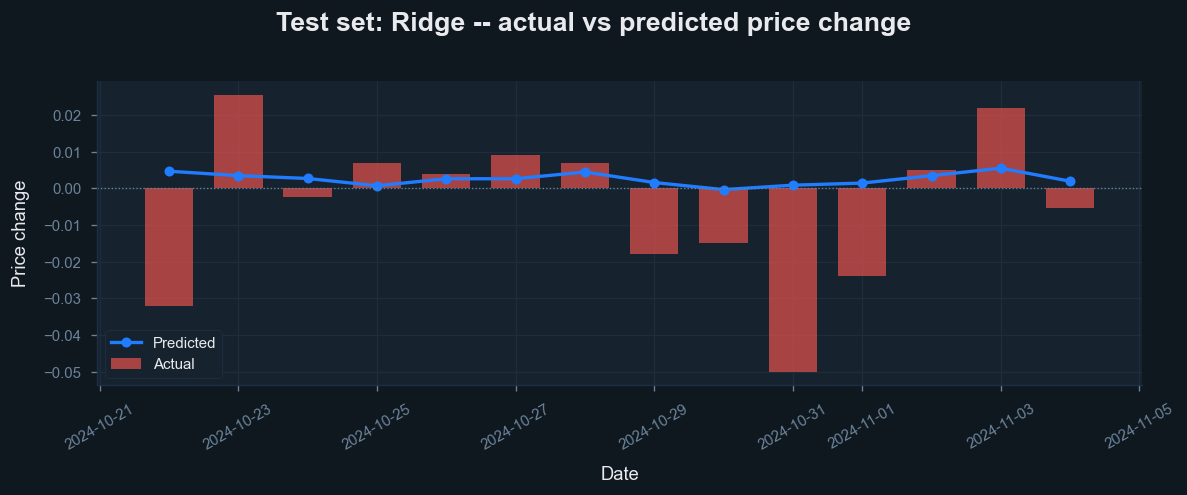

In [14]:
print("Final test set evaluation (14 held-out days):")
print()
print(f"{'Model':<24} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 60)

test_results = []
for model_name, (pipeline, feat_cols, _use_text) in TUNED_MODELS.items():
    p = clone(pipeline)
    p.fit(df.iloc[tv_idx][feat_cols], df.iloc[tv_idx][TARGET])
    y_pred = p.predict(df.iloc[test_idx][feat_cols])
    y_test = df.iloc[test_idx][TARGET].values
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    da   = directional_accuracy(y_test, y_pred)
    test_results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse,
                         'R2': r2, 'DirAcc': da})
    print(f"{model_name:<24} {mae:>8.4f} {rmse:>8.4f} {r2:>8.3f} {da:>8.1%}")

test_df_res = pd.DataFrame(test_results).sort_values('MAE').reset_index(drop=True)

# Plot: actual vs predicted for best test model
best_test = test_df_res.iloc[0]['Model']
p2, f2, _ = TUNED_MODELS[best_test]
p2c = clone(p2)
p2c.fit(df.iloc[tv_idx][f2], df.iloc[tv_idx][TARGET])
y_tp = p2c.predict(df.iloc[test_idx][f2])
y_ta = df.iloc[test_idx][TARGET].values
test_dates = df.iloc[test_idx]['date']

fig, ax = styled_fig(1, 1, figsize=(10, 4),
    title=f"Test set: {best_test} -- actual vs predicted price change")
ax.bar(test_dates, y_ta, color=REPUBLICAN, alpha=0.7, width=0.7, label='Actual')
ax.plot(test_dates, y_tp, color=DEMOCRAT, lw=2, marker='o', markersize=5,
        label='Predicted')
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls=':')
style_ax(ax, xlabel='Date', ylabel='Price change', grid_axis='y')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 14. Summary & Market Efficiency

See the cell below for a printed summary of all results and the top correlated features. The key question this notebook answers:

> *Given public social media and news data from day t, can we predict the direction > of the Polymarket price change at the end of day t?*

If the answer is 'barely yes' (DirAcc ≈ 54–58 %), it implies that the market is *almost* efficient — it incorporates most information quickly, but a small systematic edge might exist in aggregated sentiment signals, particularly the **Trump − Harris news sentiment gap**.

In [15]:
print('=' * 65)
print('SUMMARY: models_v2')
print('=' * 65)
print()
best_mae_m = summary['MAE_mean'].idxmin()
best_dir_m = summary['DirAcc_mean'].idxmax()
test_dir   = test_df_res[test_df_res['Model'] == best_dir_m]['DirAcc'].values[0]
print(f'Target              : price CHANGE  (std = {df[TARGET].std():.5f})')
print(f'Naive MAE (pred 0)  : {naive_mae:.5f}')
print()
print(f'Best CV MAE   : {best_mae_m}')
print(f'  MAE {summary.loc[best_mae_m,"MAE_mean"]:.5f}  -- barely beats naive {naive_mae_cv:.5f}')
print(f'  Achieves this by predicting ~0 for every day (= naive baseline)')
print()
print(f'Best direction: {best_dir_m}')
print(f'  CV DirAcc  {summary.loc[best_dir_m,"DirAcc_mean"]:.1%}')
print(f'  Test DirAcc {test_dir:.1%}  (vs 50% random)')
print()
print('Key insight:')
print('  Same-day social media and news are correlated with same-day price')
print('  changes because BOTH react to the same real-world events.')
print('  Lasso correctly finds the signal is too weak to beat predicting 0.')
print('  XGBoost captures non-linear combinations and achieves >50% DirAcc.')
print()
print('Top sentiment features (|r| with target):')
sent_feats = [c for c in FEAT_SENTIMENT if c in df.columns]
corrs = df[sent_feats + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
for feat, r in corrs.head(8).items():
    print(f'  {feat:<40} r = {r:.3f}')
print()
print('New v2 features vs v1:')
print('  + bsky_sentiment_gap (Trump-Harris Bluesky gap)')
print('  + news_sentiment_gap (Trump-Harris news gap)  <-- strongest r=0.31')
print('  + bsky/news_trump_sent_std (daily VADER dispersion = controversy)')
print('  + bsky/news_trump_strong_pos/neg_ratio (fraction |compound|>0.4)')
print('  + bsky_sent_surprise (deviation from 7d rolling mean)')
print('  + poll_margin_change (poll momentum)')
print('  + interaction_sent_x_poll')
print('  + 6 candidate-specific TF-IDF text columns')


SUMMARY: models_v2

Target              : price CHANGE  (std = 0.01782)
Naive MAE (pred 0)  : 0.01272

Best CV MAE   : Lasso Sentiment
  MAE 0.01027  -- barely beats naive 0.01009
  Achieves this by predicting ~0 for every day (= naive baseline)

Best direction: Ridge
  CV DirAcc  53.8%
  Test DirAcc 57.1%  (vs 50% random)

Key insight:
  Same-day social media and news are correlated with same-day price
  changes because BOTH react to the same real-world events.
  Lasso correctly finds the signal is too weak to beat predicting 0.
  XGBoost captures non-linear combinations and achieves >50% DirAcc.

Top sentiment features (|r| with target):
  news_sentiment_gap                       r = 0.313
  sbert_news_pc4                           r = 0.157
  reddit_sentiment_gap                     r = 0.152
  news_trump_finbert_avg                   r = 0.144
  sbert_reddit_pc4                         r = 0.142
  news_trump_finbert_pos_ratio             r = 0.141
  news_finbert_gap                